In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from transformers import GPT2LMHeadModel, GPT2Tokenizer, logging
import torch

logging.set_verbosity_error()

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2-large').to(device)
#
model.eval();

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

In [4]:
num_embed = model.config.n_embd
num_layer = model.config.n_layer
num_head = model.config.n_head
head_size = num_embed // num_head

num_embed, num_layer, num_head, head_size

(1280, 36, 20, 64)

# Implant hook

In [5]:
activations_A = {}

def get_activation_A(layer_num):
    def hook(module, input):
        x = input[0]   # shape: [batch, seq, hidden]
        # print(f'Module Name {module.__class__.__name__}')
        # print(f'Input Type: {type(input)}')
        # print(f'Input Length: {len(input)}')
        # print(f'Input Shape: {x.shape}')

        num_batches, num_tokens, hidden_size = x.shape
        heads = x.reshape(num_batches, num_tokens, num_head, head_size)

        activations_A[f'L{layer_num}'] = heads.detach().clone()
        return None
    return hook

handles = []
for i in range(num_layer):
  handle = model.transformer.h[i].attn.c_proj.register_forward_pre_hook(get_activation_A(i))
  handles.append(handle)

# Import texts

In [6]:
text_A = 'When Sam and Sally went to the park, Sam gave a gift to'
text_B = 'When Sam and Sally went to the park, Sally gave a gift to'

tokens_A = tokenizer.encode(text_A, return_tensors='pt').to(device)
tokens_B = tokenizer.encode(text_B, return_tensors='pt').to(device)

target_A = tokenizer.encode(' Sam', return_tensors='pt')[0]
target_B = tokenizer.encode(' Sally', return_tensors='pt')[0]

target_A, target_B

(tensor([3409]), tensor([25737]))

# Get IOI (Indefinite Object Identification) for clean run

In [7]:
# Run for text A
with torch.no_grad(): outA = model(tokens_A)

# Remove the hook handle
for handle in handles:
  handle.remove()

# run for text B
with torch.no_grad(): outB = model(tokens_B)

# Remove the hook handle
for handle in handles:
  handle.remove()


In [8]:
activations_A.keys(), activations_A['L0'].shape
#

(dict_keys(['L0', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9', 'L10', 'L11', 'L12', 'L13', 'L14', 'L15', 'L16', 'L17', 'L18', 'L19', 'L20', 'L21', 'L22', 'L23', 'L24', 'L25', 'L26', 'L27', 'L28', 'L29', 'L30', 'L31', 'L32', 'L33', 'L34', 'L35']),
 torch.Size([1, 14, 20, 64]))

In [9]:
# Calculate IOI
logit_diff_A = outA.logits[0, -1, target_A] - outA.logits[0, -1, target_B]
logit_diff_B = outB.logits[0, -1, target_A] - outB.logits[0, -1, target_B]

print(f'logit_diff_A: {logit_diff_A}')
print(f'logit_diff_B: {logit_diff_B}')
#

logit_diff_A: tensor([-3.7096], device='cuda:0')
logit_diff_B: tensor([4.4918], device='cuda:0')


In [10]:
# Predict the words
tokenizer.decode(outA.logits[0, -1, :].argmax()), tokenizer.decode(outB.logits[0, -1, :].argmax())

(' Sally', ' Sam')

# Patch for all heads in all layers

In [17]:
diff_ioi = np.zeros((num_layer, num_head))
pred_word = np.zeros((num_layer, num_head),dtype=object)

for layeri in range(num_layer):
  for headi in range(num_head):

    # Define the hook function
    def hook(module, input):
      x = input[0].detach().clone()   # shape: [batch, seq, hidden]
      num_batches, num_tokens, hidden_size = x.shape

      heads = x.reshape(num_batches, num_tokens, num_head, head_size)
      heads[:,-1,headi,:] = activations_A[f'L{layeri}'][:, -1, headi, :]

      heads = heads.reshape(num_batches, num_tokens, hidden_size)

      input = (heads, *input[1:])
      return input

    h = model.transformer.h[layeri].attn.c_proj.register_forward_pre_hook(hook)

    # forward-pass with the hook
    with torch.no_grad(): outB = model(tokens_B)
    pred_word[layeri, headi] = tokenizer.decode(outB.logits[0, -1, :].argmax())

    # Remove hook
    h.remove()

    diff_ioi[layeri, headi] = outB.logits[0, -1, target_A] - outB.logits[0, -1, target_B]

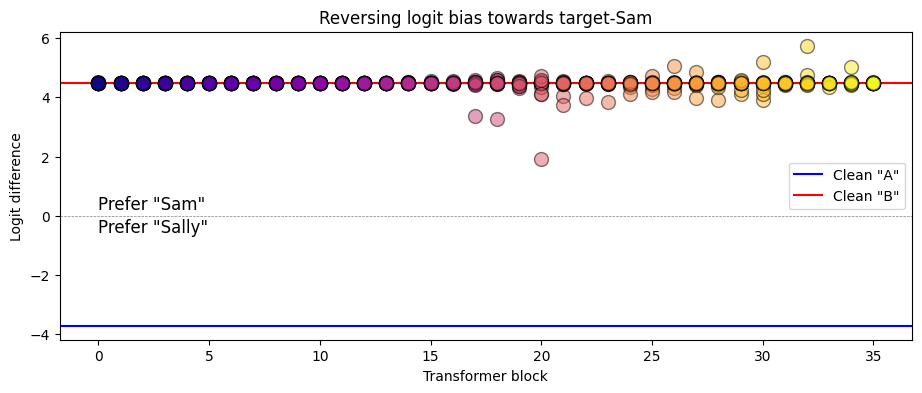

In [20]:
# Visualize
plt.figure(figsize=(11,4))

# plot the logit differences for the "clean" runs (no patching)
plt.axhline(logit_diff_A.cpu(),color='b',label='Clean "A"')
plt.axhline(logit_diff_B.cpu(),color='r',label='Clean "B"')

# then for the experiment results
for i in range(num_layer):
  plt.plot(np.ones(num_head)*i,diff_ioi[i,:],'ko',markerfacecolor=mpl.cm.plasma(i/(num_layer-1)),
           markersize=10,alpha=.5)

# the dividing line
plt.axhline(0,linestyle='--',color='gray',linewidth=.5)
plt.text(0,.1,'Prefer "Sam"',fontsize=12,va='bottom')
plt.text(0,-.1,'Prefer "Sally"',fontsize=12,va='top')

plt.gca().set(xlabel='Transformer block',ylabel='Logit difference',title='Reversing logit bias towards target-Sam')
plt.legend()
plt.show()